## Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
import os

os.makedirs('/Users/shraddhaingle/Downloads/charts', exist_ok=True)

# Load raw file
df = pd.read_csv('/Users/shraddhaingle/Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

print(f"✅ Loaded — {df.shape}")
print(f"Columns: {df.columns.tolist()}")

✅ Loaded — (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


## Encode All Columns

In [2]:
ml_df = df.copy()
ml_df = ml_df.drop(columns=['customerID'])

# Manually encode every column
ml_df['gender']           = ml_df['gender'].map({'Male': 1, 'Female': 0})
ml_df['SeniorCitizen']    = ml_df['SeniorCitizen'].astype(int)
ml_df['Partner']          = ml_df['Partner'].map({'Yes': 1, 'No': 0})
ml_df['Dependents']       = ml_df['Dependents'].map({'Yes': 1, 'No': 0})
ml_df['PhoneService']     = ml_df['PhoneService'].map({'Yes': 1, 'No': 0})
ml_df['PaperlessBilling'] = ml_df['PaperlessBilling'].map({'Yes': 1, 'No': 0})
ml_df['Churn']            = ml_df['Churn'].map({'Yes': 1, 'No': 0})

# One-hot encode multi-category columns
ml_df = pd.get_dummies(ml_df, columns=[
    'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod'
])

# Convert booleans to int
for col in ml_df.select_dtypes(include='bool').columns:
    ml_df[col] = ml_df[col].astype(int)

print(f"✅ Encoding done")
print(f"   Shape          : {ml_df.shape}")
print(f"   Text cols left : {ml_df.select_dtypes(include='object').columns.tolist()}")
print(f"   Missing values : {ml_df.isnull().sum().sum()}")

✅ Encoding done
   Shape          : (7043, 41)
   Text cols left : []
   Missing values : 0


## Train / Test Split

In [5]:
# Import the missing StandardScaler and train_test_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = ml_df.drop(columns=['Churn'])
y = ml_df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler     = StandardScaler()  # Now StandardScaler is properly imported
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"✅ Split done")
print(f"   Train : {X_train.shape}")
print(f"   Test  : {X_test.shape}")

✅ Split done
   Train : (5634, 40)
   Test  : (1409, 40)


## Logistic Regression

In [6]:
lr = LogisticRegression(max_iter=5000, random_state=42)
lr.fit(X_train_sc, y_train)

lr_preds = lr.predict(X_test_sc)
lr_probs = lr.predict_proba(X_test_sc)[:, 1]

print("=" * 45)
print("      LOGISTIC REGRESSION RESULTS")
print("=" * 45)
print(f"   Accuracy : {accuracy_score(y_test, lr_preds)*100:.1f}%")
print(f"   ROC-AUC  : {roc_auc_score(y_test, lr_probs):.3f}")
print()
print(classification_report(y_test, lr_preds,
      target_names=['Retained', 'Churned']))

      LOGISTIC REGRESSION RESULTS
   Accuracy : 80.7%
   ROC-AUC  : 0.842

              precision    recall  f1-score   support

    Retained       0.85      0.89      0.87      1035
     Churned       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



## Random Forest Classifier

In [7]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

print("=" * 45)
print("         RANDOM FOREST RESULTS")
print("=" * 45)
print(f"   Accuracy : {accuracy_score(y_test, rf_preds)*100:.1f}%")
print(f"   ROC-AUC  : {roc_auc_score(y_test, rf_probs):.3f}")
print()
print(classification_report(y_test, rf_preds,
      target_names=['Retained', 'Churned']))

         RANDOM FOREST RESULTS
   Accuracy : 78.1%
   ROC-AUC  : 0.817

              precision    recall  f1-score   support

    Retained       0.83      0.89      0.86      1035
     Churned       0.61      0.49      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



## Model Comparison Chart

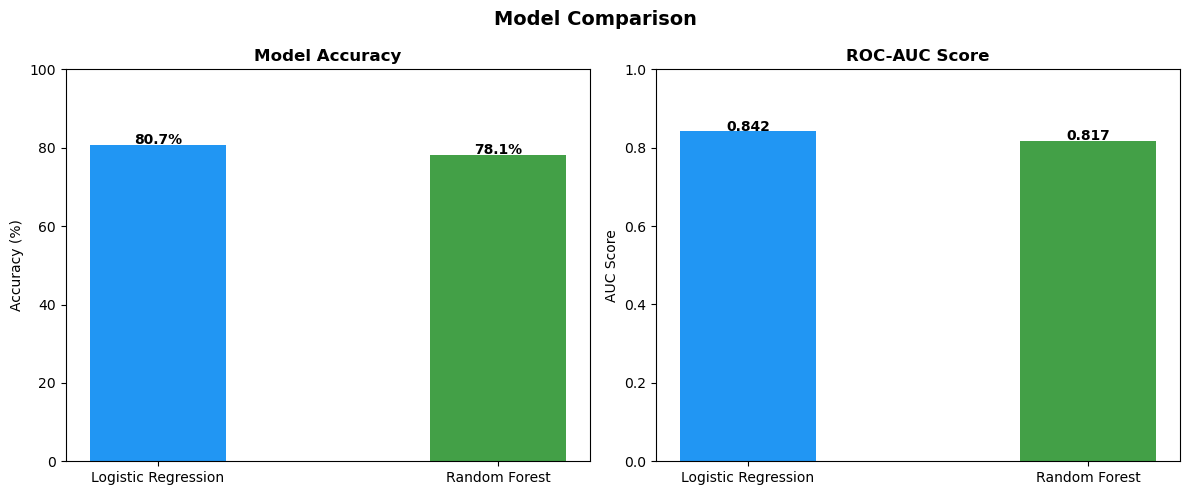

In [8]:
models     = ['Logistic Regression', 'Random Forest']
accuracies = [accuracy_score(y_test, lr_preds)*100,
              accuracy_score(y_test, rf_preds)*100]
aucs       = [roc_auc_score(y_test, lr_probs),
              roc_auc_score(y_test, rf_probs)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars = axes[0].bar(models, accuracies, color=['#2196F3', '#43A047'], width=0.4)
for bar, val in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('Model Accuracy', fontweight='bold')
axes[0].set_ylim(0, 100)
axes[0].set_ylabel('Accuracy (%)')

bars = axes[1].bar(models, aucs, color=['#2196F3', '#43A047'], width=0.4)
for bar, val in zip(bars, aucs):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{val:.3f}', ha='center', fontweight='bold')
axes[1].set_title('ROC-AUC Score', fontweight='bold')
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('AUC Score')

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/shraddhaingle/Downloads/charts/07_model_comparison.png', dpi=150)
plt.show()

##  ROC Curve

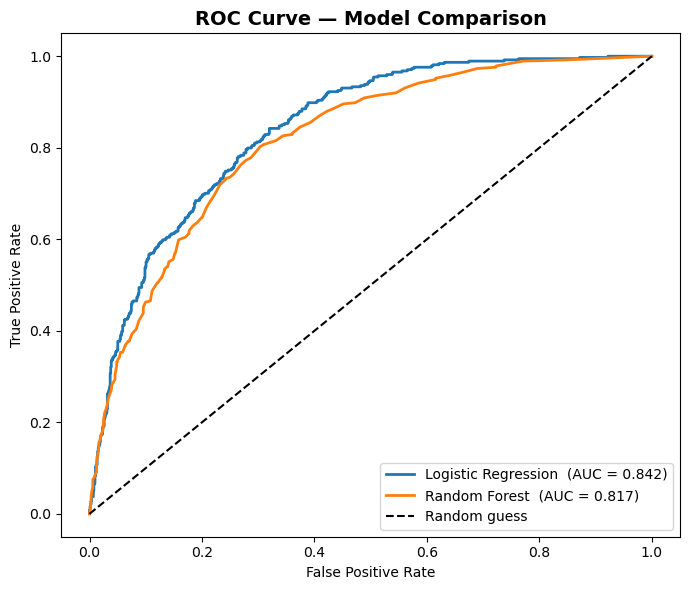

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, probs in [('Logistic Regression', lr_probs),
                    ('Random Forest', rf_probs)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f'{name}  (AUC = {auc:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random guess')
ax.set_title('ROC Curve — Model Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.tight_layout()
plt.savefig('/Users/shraddhaingle/Downloads/charts/08_roc_curve.png', dpi=150)
plt.show()

## Feature Importance

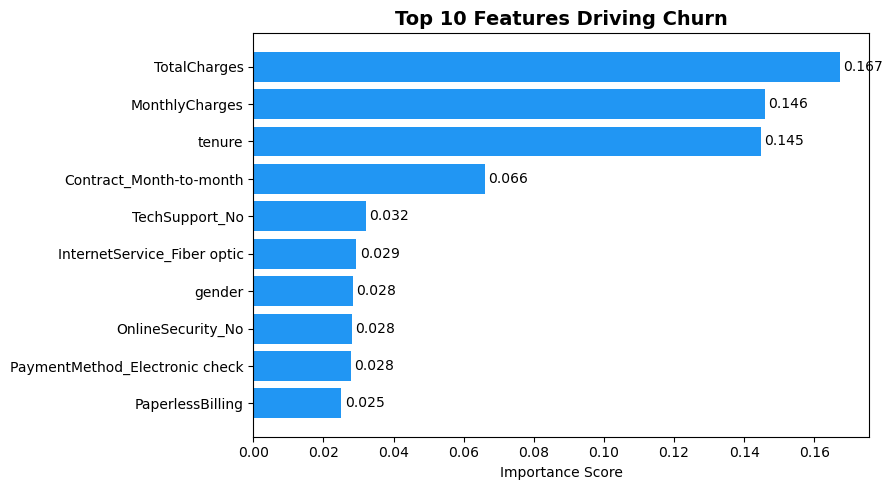


Top 3 features:
TotalCharges      0.167339
MonthlyCharges    0.145886
tenure            0.144680


In [10]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
top10 = importance.sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top10.index[::-1], top10.values[::-1], color='#2196F3')

for bar, val in zip(bars, top10.values[::-1]):
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

ax.set_title('Top 10 Features Driving Churn', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('/Users/shraddhaingle/Downloads/charts/09_feature_importance.png', dpi=150)
plt.show()

print("\nTop 3 features:")
print(top10.head(3).to_string())

## Confusion Matrix

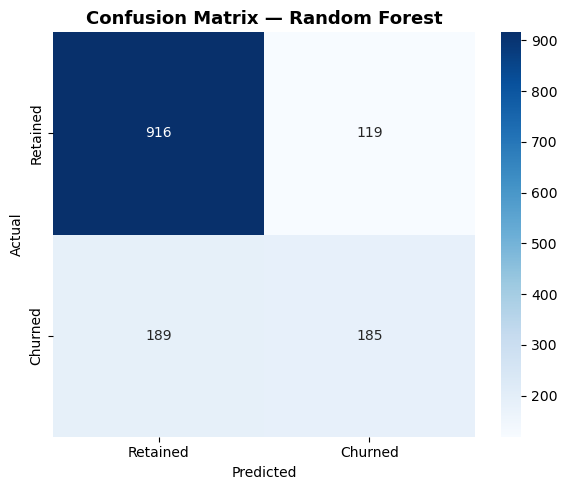

Correctly identified churners    : 185
Missed churners (false negatives): 189
False alarms    (false positives): 119


In [11]:
cm = confusion_matrix(y_test, rf_preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'])

ax.set_title('Confusion Matrix — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('/Users/shraddhaingle/Downloads/charts/10_confusion_matrix.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Correctly identified churners    : {tp}")
print(f"Missed churners (false negatives): {fn}")
print(f"False alarms    (false positives): {fp}")

## Save Risk Scores

In [12]:
df['churn_probability'] = rf.predict_proba(X)[:, 1]
df['risk_tier'] = pd.cut(
    df['churn_probability'],
    bins=[0, 0.3, 0.6, 0.8, 1.0],
    labels=['Low', 'Medium', 'High', 'Critical']
)

df.to_csv('/Users/shraddhaingle/Downloads/predictions.csv', index=False)

print("✅ All done — charts saved to Downloads/charts/")
print("\nRisk tier breakdown:")
print(df['risk_tier'].value_counts().sort_index().to_string())

✅ All done — charts saved to Downloads/charts/

Risk tier breakdown:
risk_tier
Low         3798
Medium       413
High         781
Critical     894


In [13]:
df = pd.read_csv('/Users/shraddhaingle/Downloads/predictions.csv')
print(df['Churn'].unique())
print(df['Churn'].dtype)

['No' 'Yes']
object


In [14]:
import pandas as pd

df = pd.read_csv('/Users/shraddhaingle/Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# Add numeric churn column — 1 for churned, 0 for retained
df['Churned']          = (df['Churn'] == 'Yes').astype(int)
df['Is_Month_to_Month'] = (df['Contract'] == 'Month-to-month').astype(int)

# Keep only columns Tableau needs
tableau_df = df[[
    'customerID', 'gender', 'SeniorCitizen', 'Partner',
    'Dependents', 'tenure', 'Contract', 'InternetService',
    'OnlineSecurity', 'TechSupport', 'PaymentMethod',
    'MonthlyCharges', 'TotalCharges', 'Churn', 'Churned'
]]

tableau_df.to_csv('/Users/shraddhaingle/Downloads/tableau_churn.csv', index=False)

print(f"✅ Saved — {len(tableau_df):,} rows")
print(f"\nChurn column sample:")
print(tableau_df[['Churn','Churned']].head(5))
print(f"\nChurned average: {tableau_df['Churned'].mean():.3f}")

✅ Saved — 7,043 rows

Churn column sample:
  Churn  Churned
0    No        0
1    No        0
2   Yes        1
3    No        0
4   Yes        1

Churned average: 0.265


In [17]:
import pandas as pd

df = pd.read_csv('/Users/shraddhaingle/Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df['Churned'] = (df['Churn'] == 'Yes').astype(int)

df.to_csv('/Users/shraddhaingle/Downloads/tableau_churn.csv', index=False)

print(f"✅ Saved")
print(df[['Churn','Churned']].head(3))

✅ Saved
  Churn  Churned
0    No        0
1    No        0
2   Yes        1


In [18]:
import pandas as pd

# Load both files
raw = pd.read_csv('/Users/shraddhaingle/Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv')
pred = pd.read_csv('/Users/shraddhaingle/Downloads/predictions.csv')

# Clean
raw['TotalCharges'] = pd.to_numeric(raw['TotalCharges'], errors='coerce').fillna(0)
raw['Churned'] = (raw['Churn'] == 'Yes').astype(int)

# Add risk tier and churn probability from predictions
raw['Risk Tier']         = pred['risk_tier']
raw['Churn Probability'] = pred['churn_probability']

# Save
raw.to_csv('/Users/shraddhaingle/Downloads/tableau_churn.csv', index=False)

print(f"✅ Saved — {len(raw):,} rows")
print(f"\nRisk Tier values:")
print(raw['Risk Tier'].value_counts())

✅ Saved — 7,043 rows

Risk Tier values:
Risk Tier
Low         3798
Critical     894
High         781
Medium       413
Name: count, dtype: int64


In [19]:
import pandas as pd

# Load both files
raw = pd.read_csv('/Users/shraddhaingle/Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv')
pred = pd.read_csv('/Users/shraddhaingle/Downloads/predictions.csv')

# Clean
raw['TotalCharges'] = pd.to_numeric(raw['TotalCharges'], errors='coerce').fillna(0)
raw['Churned'] = (raw['Churn'] == 'Yes').astype(int)

# Add risk tier and churn probability from predictions
raw['Risk Tier']         = pred['risk_tier']
raw['Churn Probability'] = pred['churn_probability']

# Save
raw.to_csv('/Users/shraddhaingle/Downloads/tableau_churn.csv', index=False)

print(f"✅ Saved — {len(raw):,} rows")
print(f"\nRisk Tier values:")
print(raw['Risk Tier'].value_counts())

✅ Saved — 7,043 rows

Risk Tier values:
Risk Tier
Low         3798
Critical     894
High         781
Medium       413
Name: count, dtype: int64
